In [ ]:
!pip install import_ipynb
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/МИФИ Машинное обучение/Классическое машинное обучение/')

import import_ipynb
import regression_pipeline as pipelines

In [10]:
result = pipelines.run_regression_task(pipelines.RegressionTask(name="IC50", target_column="log_IC50, mM"), True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'fit model'

'Ridge'

{'task': 'IC50',
 'model': 'Ridge',
 'cv_r2_mean': 0.3081677448611292,
 'test_mae': 0.7096820563190702,
 'test_rmse': np.float64(1.1705677547564182),
 'test_r2': -0.3278194500131222,
 'best_params': '{"model__alpha": 0.01, "selector__k": 50}'}

'fit model'

...

'GradientBoosting'

{'task': 'IC50',
 'model': 'GradientBoosting',
 'cv_r2_mean': 0.41686269685994476,
 'test_mae': 0.5869428654453562,
 'test_rmse': np.float64(0.7250616511981076),
 'test_r2': 0.49055678293829863,
 'best_params': '{"selector__k": 50, "model__subsample": 0.7, "model__n_estimators": 200, "model__min_samples_split": 2, "model__min_samples_leaf": 2, "model__max_depth": 3, "model__learning_rate": 0.02}'}

'fit model'

'XGBoost'

{'task': 'IC50',
 'model': 'XGBoost',
 'cv_r2_mean': 0.4310901385456205,
 'test_mae': 0.5780101667542128,
 'test_rmse': np.float64(0.7268114850980639),
 'test_r2': 0.4880948772690714,
 'best_params': '{"selector__k": 25, "model__subsample": 0.85, "model__n_estimators": 100, "model__max_depth": 5, "model__learning_rate": 0.05}'}

Выводы:
Для решения задачи регрессии был написан пайплан который использовал различные линейные и ансамблевые модели с использованием автоматизированного подбора гиперпараметров (GridSearchCV и RandomizedSearchCV) гиперпараметров. По итогу получились следующее:

1. Линейные модели полностью провались, отрицательный коэффициент детерминации не оставляет шансов, модели просто не объясняет дисперсию. Это логично, тк пространсво биохимических реакций нелинейно и имеет множество сложных зависимостей, которые линейные модели не могут обобщить.
2. Анасаблевые модели справились хорошо, лучшего всего справился RF, подбор гиперпараметров улучшил базовые параметры, при этом переобучения не случилось($R^2$ теста выше $R^2$ для кросс валидации, те модель не зазубрила тестовый набор). Итог - 0.506 что позволяет объяснить чуть больше половины всей дисперсии, чего достаточно для приоритезации кандидатов на дальнейшие испытания. Ниже представлена статистика для моделей и графики для лучшей модели.

## Сводная таблица метрик

| Модель | $R^2$ | CV $R^2$ (mean) | MAE | RMSE | Лучшие параметры|
| :--- | :---: | :---: | :---: | :---: | :--- |
| **RandomForest** | **0.5061** | 0.4440 | 0.5626 | 0.7139 | k: 25, n_est: 600, depth: 20, leaf: 2 |
| **GradientBoosting** | **0.4906** | 0.4169 | 0.5869 | 0.7251 | k: 50, n_est: 200, depth: 3, lr: 0.02 |
| **XGBoost** | **0.4881** | 0.4311 | 0.5780 | 0.7268 | k: 25, n_est: 100, depth: 5, lr: 0.05 |
| **Lasso** | **-0.1519** | 0.3070 | 0.6985 | 1.0903 | k: 50, alpha: 0.001 |
| **ElasticNet** | **-0.2165** | 0.3079 | 0.7030 | 1.1204 | k: 50, alpha: 0.001, l1_ratio: 0.2 |
| **Ridge** | **-0.3278** | 0.3082 | 0.7097 | 1.1706 | k: 50, alpha: 0.01 |

---
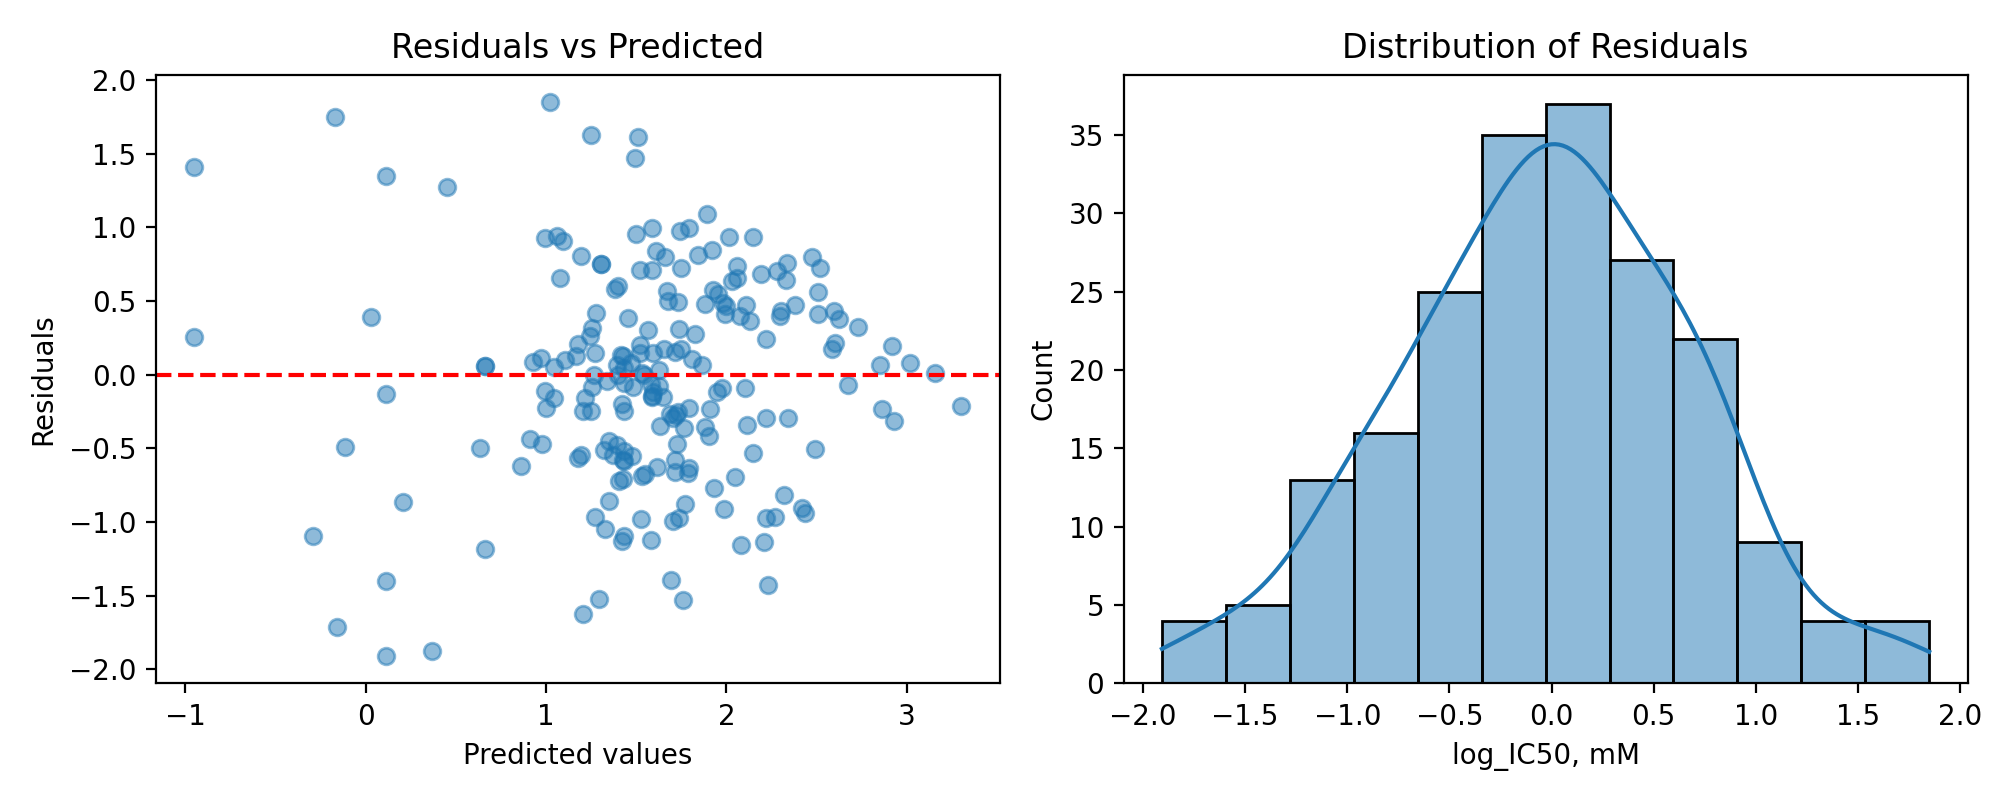

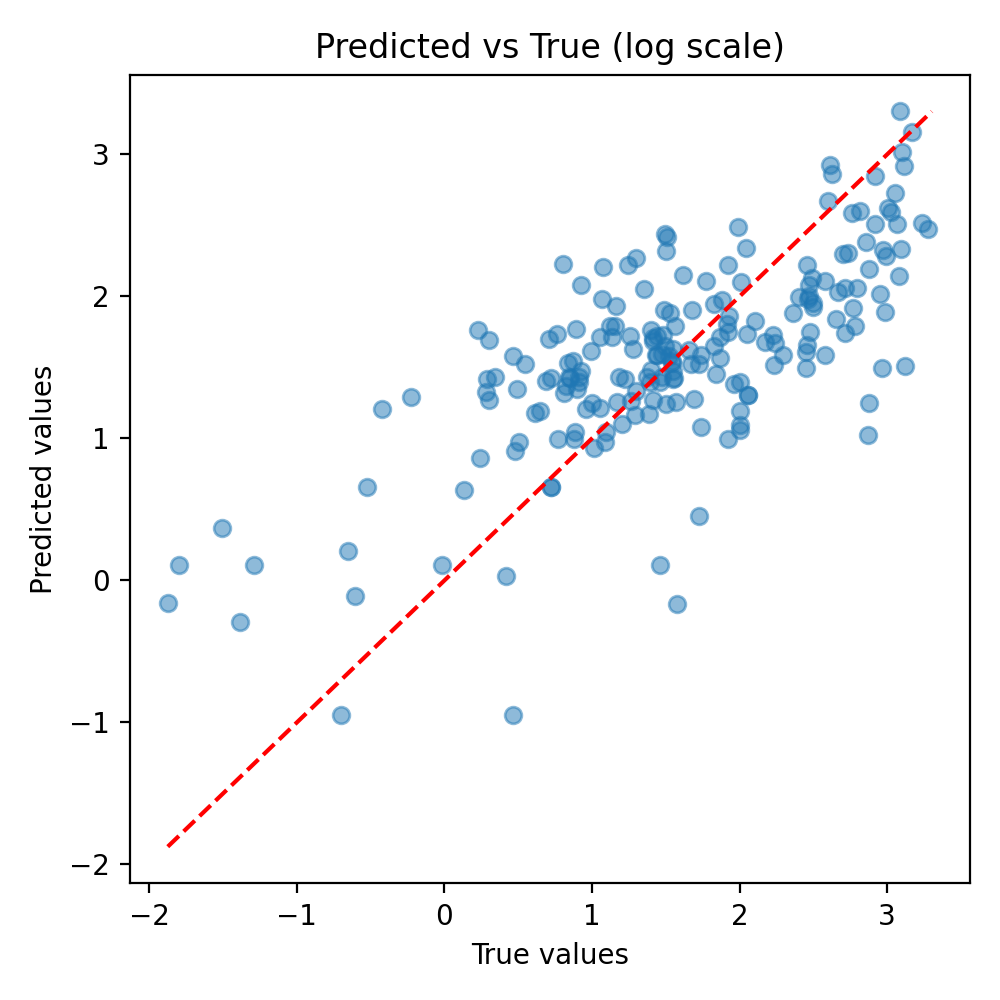


Рекомендации по улучшению:

1. Дополнительны Feature Engineering: изменение набора дескрипторов и консультация специалиста в данной области.
2. Создание ансамбля на основе RandomForest и XGBoost для дальнейшего снижения ошибки.
3. Изучение молекул-выбросов (см Residuals) для выявления специфических паттернов активности, а также добавление в выборку новых молекул(зона график с -2 по 0, точки выше диагонали и 2.5-3, точки ниже диагонали, модель систематически ошибавется завышая/занижая предсказание).